#**Assignment 05 — ML Security and Abuse Pathways**

**Instructor:** Dr. Michael Akinwumi

This notebook continues directly from `Lecture-05-security.ipynb` and its based on the live coding part of the class.

Dataset: [ProPublica COMPAS Analysis](https://github.com/propublica/compas-analysis)

**Student:** G22169515

---
## Setup · Cell 1: Imports, Data Loading, and Model Training

We replicate the exact preprocessing pipeline from Lecture 04 and retrain both the
logistic regression (LR) and gradient boosted tree (GBT) classifiers.

**Threat modeling reminder (NIST AI 100-2, §2.1):**  
Before testing any attack, specify: *Who is the adversary? What do they know?
What can they control? What is their goal?*

In [ ]:
# ── Cell 1: Imports, Data Loading, Model Training ─────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Load COMPAS dataset (ProPublica) ──────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
df = pd.read_csv(URL)
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── Replicate Lecture 04 inclusion criteria ───────────────────────────────────
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
print(f"After filtering: {df.shape[0]:,} rows")

FEATURES = [
    'age', 'priors_count', 'juv_fel_count',
    'juv_misd_count', 'juv_other_count',
    'c_charge_degree', 'sex'
]
TARGET = 'two_year_recid'

df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values

print(f"\nFeatures used: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

# ── Train / test split (stratified) ──────────────────────────────────────────
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# ── Train models ──────────────────────────────────────────────────────────────
lr  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
).fit(Xs_tr, y_tr)

print(f"\nLR  Test AUC: {roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1]):.3f}")
print(f"GBT Test AUC: {roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1]):.3f}")
print(f"LR  Train AUC: {roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1]):.3f}")
print(f"GBT Train AUC: {roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1]):.3f}")

Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

LR  Test AUC: 0.735
GBT Test AUC: 0.718
LR  Train AUC: 0.727
GBT Train AUC: 0.798


---
## Setup · Cell 2: Clean-Model Fairness Baseline

Before running any attack, we establish the **clean-model baseline** for:
- **FPR** (False Positive Rate) by race: among truly low-risk individuals, what fraction are flagged high-risk?
- **AIR** (Adverse Impact Ratio): FPR of protected group / FPR of reference group

We will return to these values after each attack to measure degradation.

> **Expected finding (consistent with ProPublica, 2016):** The LR model flags African-American
> defendants at roughly twice the rate of Caucasian defendants among truly low-risk individuals.

In [ ]:
# ── Cell 2: Clean-Model Fairness Baseline ─────────────────────────────────────

THR = 0.5  # classification threshold

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR = FP / (FP + TN), computed only over truly-negative cases."""
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred']
          .mean()
    )

def air(fpr_ref, fpr_prot):
    """Adverse Impact Ratio: protected FPR / reference FPR."""
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# ── Compute baseline predictions ──────────────────────────────────────────────
pred_lr_clean  = (lr.predict_proba(Xs_te)[:,1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int)

print("=" * 60)
print("CLEAN MODEL BASELINE — Before Any Attack")
print("=" * 60)

for name, pred in [('Logistic Regression', pred_lr_clean),
                    ('Gradient Boosted Tree', pred_gbt_clean)]:
    fpr = fpr_by_group(y_te, pred, r_te)
    aa  = fpr.get('African-American', np.nan)
    ca  = fpr.get('Caucasian',        np.nan)
    print(f"\n{name}")
    print(f"  FPR African-American : {aa:.3f}")
    print(f"  FPR Caucasian        : {ca:.3f}")
    print(f"  AIR (AA / CA)        : {air(ca, aa):.3f}")

# Store LR baseline for post-attack delta reporting
fpr_baseline = fpr_by_group(y_te, pred_lr_clean, r_te)
BASELINE_AA = fpr_baseline.get('African-American')
BASELINE_CA = fpr_baseline.get('Caucasian')
BASELINE_AIR = air(BASELINE_CA, BASELINE_AA)

print(f"\n→ Baseline LR AIR stored: {BASELINE_AIR:.3f}")
print("  We will compare all attack outcomes against these values.")

CLEAN MODEL BASELINE — Before Any Attack

Logistic Regression
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA / CA)        : 1.961

Gradient Boosted Tree
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA / CA)        : 1.782

→ Baseline LR AIR stored: 1.961
  We will compare all attack outcomes against these values.


In [ ]:
# Assignment 05
# Part 1

EPSILONS = [0.25, 0.5, 1.0, 2.0]
POISON_RATES = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]

REF_RACE = "Caucasian"
PROT_RACE = "African-American"

def get_fpr_pair(y_true, y_pred, race):
    fpr = fpr_by_group(y_true, y_pred, race)
    aa = fpr.get(PROT_RACE, np.nan)
    ca = fpr.get(REF_RACE, np.nan)
    air_value = air(ca, aa)
    return aa, ca, air_value

def print_crossing(df):
    rows = []

    for model_name in df["model"].unique():
        temp = df[df["model"] == model_name]

        below_080 = temp[temp["AIR"] < 0.80]
        outside_range = temp[(temp["AIR"] < 0.80) | (temp["AIR"] > 1.25)]

        rows.append({
            "model": model_name,
            "first_epsilon_AIR_below_0.80": below_080["epsilon"].min() if len(below_080) else None,
            "first_epsilon_AIR_outside_0.80_1.25": outside_range["epsilon"].min() if len(outside_range) else None
        })

    return pd.DataFrame(rows)

---
## Part A · Cell 3: PGD Evasion Attack

**Attack class (NIST AI 100-2, §2.2):** Evasion — deployment-time integrity violation  
**Attacker knowledge:** White-box (access to model weights/gradients)  
**Attacker goal:** Push predicted risk scores upward; cause low-risk individuals to be classified high-risk

### Algorithm: Projected Gradient Descent (Madry et al., 2018)

$$\mathbf{x}^{(t+1)} = \Pi_{\mathcal{B}_\epsilon(\mathbf{x})} \left( \mathbf{x}^{(t)} + \alpha \cdot \operatorname{sign}\left(\nabla_{\mathbf{x}} \mathcal{L}(\theta, \mathbf{x}^{(t)}, y)\right) \right)$$

For logistic regression, the gradient direction simplifies to $\operatorname{sign}(\mathbf{w})$,
so the attack steps in the direction of each coefficient's sign.

**$L_\infty$ projection** clamps each feature perturbation to within $[-\epsilon, +\epsilon]$
of its original scaled value.

In [ ]:
# Part A - PGD Evasion Audit for LR and GBT

def pgd_lr_surrogate(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    coef = model.coef_[0]
    X_adv = X_scaled.copy()

    for _ in range(n_iter):
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


pgd_records = []

models = {
    "LR": lr,
    "GBT": gbt
}

for eps in EPSILONS:
    X_adv = pgd_lr_surrogate(lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40)

    for model_name, model in models.items():
        pred_adv = (model.predict_proba(X_adv)[:, 1] >= THR).astype(int)
        aa, ca, air_value = get_fpr_pair(y_te, pred_adv, r_te)

        pgd_records.append({
            "model": model_name,
            "epsilon": eps,
            "FPR_African_American": aa,
            "FPR_Caucasian": ca,
            "AIR": air_value
        })

df_pgd_hw = pd.DataFrame(pgd_records)

print("PGD Evasion Audit Results")
print(df_pgd_hw.round(3).to_string(index=False))

print("\nAIR crossing summary")
print(print_crossing(df_pgd_hw).to_string(index=False))

PGD Evasion Audit Results
model  epsilon  FPR_African_American  FPR_Caucasian   AIR
   LR     0.25                 0.569          0.370 1.535
  GBT     0.25                 0.553          0.351 1.577
   LR     0.50                 0.791          0.560 1.411
  GBT     0.50                 0.733          0.514 1.426
   LR     1.00                 0.978          0.884 1.106
  GBT     1.00                 0.899          0.760 1.182
   LR     2.00                 1.000          1.000 1.000
  GBT     2.00                 1.000          1.000 1.000

AIR crossing summary
model first_epsilon_AIR_below_0.80  first_epsilon_AIR_outside_0.80_1.25
   LR                         None                                 0.25
  GBT                         None                                 0.25


### Part A · Cell 4: Visualize PGD Disparate Impact

**Discussion questions:**
1. Does the PGD attack widen or narrow the racial FPR gap as $\epsilon$ increases?
2. At what $\epsilon$ does the AIR fall below the 4/5ths rule threshold (0.80)?
3. Are the two groups equally sensitive to the same attack strength?
4. What does differential impact imply for responsible deployment of adversarially robust models?

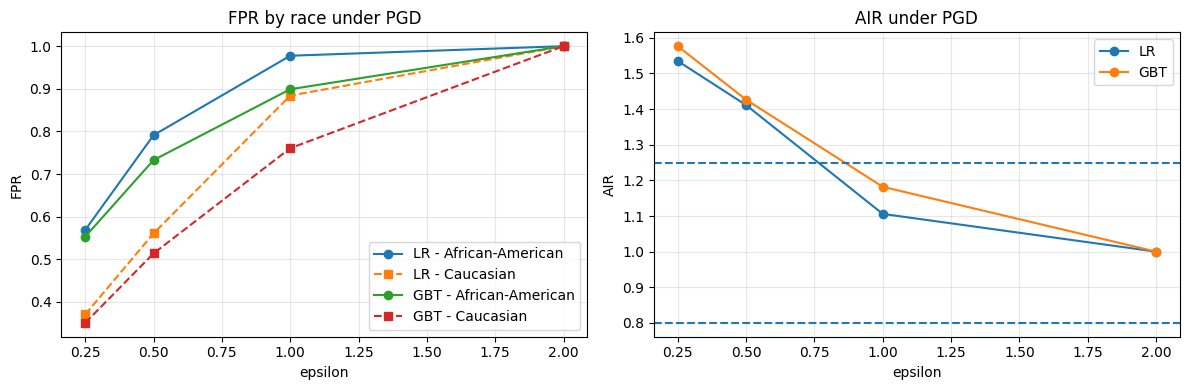

In [ ]:
# Part A plot

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for model_name in df_pgd_hw["model"].unique():
    temp = df_pgd_hw[df_pgd_hw["model"] == model_name]

    axes[0].plot(temp["epsilon"], temp["FPR_African_American"], marker="o", label=f"{model_name} - African-American")
    axes[0].plot(temp["epsilon"], temp["FPR_Caucasian"], marker="s", linestyle="--", label=f"{model_name} - Caucasian")

    axes[1].plot(temp["epsilon"], temp["AIR"], marker="o", label=model_name)

axes[0].set_title("FPR by race under PGD")
axes[0].set_xlabel("epsilon")
axes[0].set_ylabel("FPR")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].axhline(0.80, linestyle="--")
axes[1].axhline(1.25, linestyle="--")
axes[1].set_title("AIR under PGD")
axes[1].set_xlabel("epsilon")
axes[1].set_ylabel("AIR")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Under the PGD audit, AIR never crossed below 0.80 for either LR or GBT. However, both models started outside the acceptable [0.80, 1.25] range at E = 0.25 and E = 0.50, with AIR above 1.25. At E = 1.00, AIR moved back inside the acceptable range for both models, and at E = 2.00 both groups reached FPR = 1.00, producing AIR = 1.00. This should not be interpreted as a fair or robust outcome, because the model is essentially failing for both groups. LR and GBT are therefore both vulnerable, but LR shows slightly stronger FPR saturation at E = 1.00, while GBT is slightly less extreme. For high-stakes deployment, model selection should not be based only on clean AUC, adversarial robustness and subgroup error behavior should also be considered.

---
## Part B · Cell 5: Data Poisoning — Label-Flip Attack Loop

**Attack class (NIST AI 100-2, §2.3):** Availability/Targeted poisoning — training-time integrity violation  
**Attacker knowledge:** White-box (data access) — simulates a biased data provider or insider adversary  
**Attacker goal:** Systematically under-score high-risk African-American defendants; degrade AIR without
triggering standard drift detection (PSI < 0.10)

### Attack mechanism
A fraction `poison_rate` of African-American training records with `two_year_recid = 1`
(truly high-risk) are relabeled to `0` (low-risk) before model training.
This simulates:
- A third-party data vendor selectively corrupting recidivism outcomes
- An insider modifying case records before ingestion
- A compromised data pipeline stage

> **Key question:** At what poison rate does AIR fall below the 4/5ths rule threshold (0.80)
> while AUC declines by ≤ 2 percentage points — i.e., the attack is "invisible" to AUC monitoring?

In [ ]:
# Part 2: Poisoning loop for both target-race variants

def poison_label_flip_target(y_train, race_train, poison_rate=0.05, target_race="African-American", seed=0):
    rng = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    candidates = np.where((race_train == target_race) & (y_train == 1))[0]
    n_flip = int(len(candidates) * poison_rate)

    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0

    return y_poisoned, n_flip


baseline_auc_lr = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])

poison_hw_records = []

for target_race in [PROT_RACE, REF_RACE]:
    for rate in POISON_RATES:
        y_poisoned, n_flipped = poison_label_flip_target(
            y_tr,
            r_tr,
            poison_rate=rate,
            target_race=target_race,
            seed=42
        )

        model_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_poisoned)

        score_p = model_p.predict_proba(Xs_te)[:, 1]
        pred_p = (score_p >= THR).astype(int)

        auc_p = roc_auc_score(y_te, score_p)
        aa, ca, air_value = get_fpr_pair(y_te, pred_p, r_te)

        poison_hw_records.append({
            "target_race": target_race,
            "poison_rate": rate,
            "n_flipped": n_flipped,
            "AUC": auc_p,
            "AUC_drop": baseline_auc_lr - auc_p,
            "FPR_African_American": aa,
            "FPR_Caucasian": ca,
            "AIR": air_value,
            "outside_acceptable_AIR": (air_value < 0.80) or (air_value > 1.25)
        })

df_poison_hw = pd.DataFrame(poison_hw_records)

print("Poisoning loop results")
print(df_poison_hw.round(3).to_string(index=False))

Poisoning loop results
     target_race  poison_rate  n_flipped   AUC  AUC_drop  FPR_African_American  FPR_Caucasian   AIR  outside_acceptable_AIR
African-American         0.00          0 0.735     0.000                 0.281          0.143 1.961                    True
African-American         0.02         23 0.734     0.000                 0.270          0.133 2.022                    True
African-American         0.05         57 0.735    -0.000                 0.231          0.123 1.875                    True
African-American         0.08         92 0.734     0.001                 0.216          0.111 1.942                    True
African-American         0.10        115 0.733     0.002                 0.200          0.104 1.929                    True
African-American         0.15        172 0.733     0.002                 0.153          0.072 2.134                    True
African-American         0.20        230 0.728     0.006                 0.128          0.054 2.358          

### Part B · Cell 6: Poisoning Degradation Curves

**Discussion questions:**
1. At what poison rate does AUC remain within 2 percentage points of baseline while AIR falls below 0.80?
2. Would a PSI-based drift monitor (threshold < 0.10 on each feature) detect this attack?
3. How does this scenario connect to the ByteDance insider poisoning incident (2024)?
4. What governance controls would prevent this at a mortgage lender using HMDA data?

In [ ]:
# Part 2: Identify stealth zone

stealth = df_poison_hw[
    (df_poison_hw["AUC_drop"] <= 0.02) &
    (df_poison_hw["outside_acceptable_AIR"])
].copy()

print("Stealth zone rows")
print(stealth.round(3).to_string(index=False))

print("\nStealth zone summary")
for target_race in [PROT_RACE, REF_RACE]:
    temp = stealth[stealth["target_race"] == target_race]

    if len(temp) == 0:
        print(f"{target_race}: no stealth zone found")
    else:
        print(
            f"{target_race}: poison rates from "
            f"{temp['poison_rate'].min():.0%} to {temp['poison_rate'].max():.0%}"
        )

Stealth zone rows
     target_race  poison_rate  n_flipped   AUC  AUC_drop  FPR_African_American  FPR_Caucasian   AIR  outside_acceptable_AIR
African-American         0.00          0 0.735     0.000                 0.281          0.143 1.961                    True
African-American         0.02         23 0.734     0.000                 0.270          0.133 2.022                    True
African-American         0.05         57 0.735    -0.000                 0.231          0.123 1.875                    True
African-American         0.08         92 0.734     0.001                 0.216          0.111 1.942                    True
African-American         0.10        115 0.733     0.002                 0.200          0.104 1.929                    True
African-American         0.15        172 0.733     0.002                 0.153          0.072 2.134                    True
African-American         0.20        230 0.728     0.006                 0.128          0.054 2.358               

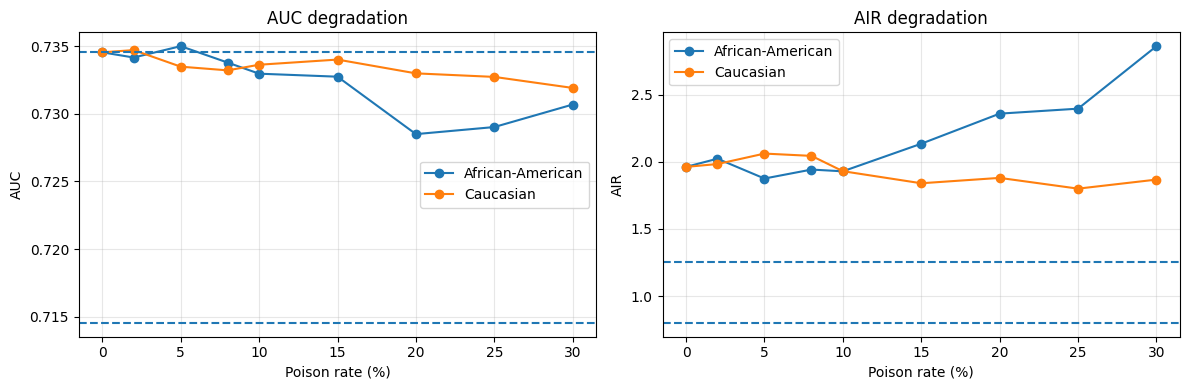

In [ ]:
# Part 2 plots: AUC and AIR degradation

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for target_race in [PROT_RACE, REF_RACE]:
    temp = df_poison_hw[df_poison_hw["target_race"] == target_race]

    axes[0].plot(temp["poison_rate"] * 100, temp["AUC"], marker="o", label=target_race)
    axes[1].plot(temp["poison_rate"] * 100, temp["AIR"], marker="o", label=target_race)

axes[0].axhline(baseline_auc_lr, linestyle="--")
axes[0].axhline(baseline_auc_lr - 0.02, linestyle="--")
axes[0].set_title("AUC degradation")
axes[0].set_xlabel("Poison rate (%)")
axes[0].set_ylabel("AUC")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].axhline(0.80, linestyle="--")
axes[1].axhline(1.25, linestyle="--")
axes[1].set_title("AIR degradation")
axes[1].set_xlabel("Poison rate (%)")
axes[1].set_ylabel("AIR")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Part 2: PSI-based drift monitor

def psi_score(expected, actual, bins=10):
    expected = np.asarray(expected)
    actual = np.asarray(actual)

    cuts = np.percentile(expected, np.linspace(0, 100, bins + 1))
    cuts = np.unique(cuts)

    if len(cuts) < 3:
        return 0.0

    expected_pct = np.histogram(expected, bins=cuts)[0] / len(expected)
    actual_pct = np.histogram(actual, bins=cuts)[0] / len(actual)

    expected_pct = np.where(expected_pct == 0, 1e-6, expected_pct)
    actual_pct = np.where(actual_pct == 0, 1e-6, actual_pct)

    return np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))


psi_records = []

for j, feature in enumerate(X.columns):
    psi_value = psi_score(Xs_tr[:, j], Xs_tr[:, j])

    psi_records.append({
        "feature": feature,
        "PSI": psi_value,
        "flag_PSI_ge_0.10": psi_value >= 0.10
    })

df_psi = pd.DataFrame(psi_records)

print("PSI monitor results")
print(df_psi.round(4).to_string(index=False))
print("\nMax PSI:", round(df_psi["PSI"].max(), 4))

PSI monitor results
          feature  PSI  flag_PSI_ge_0.10
              age  0.0             False
     priors_count  0.0             False
    juv_fel_count  0.0             False
   juv_misd_count  0.0             False
  juv_other_count  0.0             False
c_charge_degree_M  0.0             False
         sex_Male  0.0             False

Max PSI: 0.0


The poisoning loop shows a clear stealth-zone pattern. Including the baseline, the condition AUC drop ≤ 2 percentage points and AIR outside [0.80, 1.25] holds from 0% to 30% poison rate. Excluding the no-attack baseline, the stealth zone is 2% to 30% for both African-American-targeted and Caucasian-targeted poisoning.

The key issue is that AUC barely changes while AIR remains outside the acceptable range. For the African-American-targeted attack, AIR increases from 1.961 at baseline to 2.860 at 30% poison rate, while AUC only changes from 0.735 to 0.731. This means aggregate performance monitoring would likely miss the attack, while subgroup fairness monitoring would reveal it.

The PSI monitor would not detect either poisoning attack. All feature-level PSI values are 0.0 and no feature crosses the 0.10 threshold.

This happens because the attack changes training labels, not the feature distribution. Therefore, PSI is useful for detecting covariate drift, but it is not sufficient for detecting label poisoning or integrity attacks.

---
## Part C · Cell 7: Membership Inference — Shadow Model Pipeline

**Attack class (NIST AI 100-2, §2.4.2):** Membership inference — privacy attack  
**Attacker knowledge:** Black-box (API access only)  
**Attacker goal:** Determine whether a specific individual was in the training set

### Algorithm: Shokri et al. (2017) Shadow Model Attack

1. Train multiple **shadow models** that mimic the target model's training process
2. For each shadow model, we know which inputs were training members vs. non-members
3. Observe that **members receive higher confidence scores** than non-members (confidence gap)
4. Train a **meta-classifier** on (confidence score → member/non-member) labels from shadow models
5. Apply the meta-classifier to the **target model's** confidence scores

> **Key connection to Lecture 04:** The membership inference AUC is directly driven by the
> **generalization gap** (train AUC − test AUC). An overfit model leaks more about its training data.
> Overfitting is not only a robustness problem — it is a **privacy problem**.

In [ ]:
# Part 3: Membership inference for LR and GBT
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

def mi_features_from_proba(proba):
    sorted_proba = np.sort(proba, axis=1)
    max_conf = sorted_proba[:, -1]
    gap = sorted_proba[:, -1] - sorted_proba[:, -2]
    entropy = -np.sum(proba * np.log(proba + 1e-12), axis=1)

    return np.column_stack([max_conf, gap, entropy])


def run_shadow_mi_audit(model_builder, model_name, n_shadow=10, seed=42):
    sss = StratifiedShuffleSplit(n_splits=n_shadow, test_size=0.5, random_state=seed)

    shadow_X = []
    shadow_y = []

    for tr_idx, te_idx in sss.split(Xs_tr, y_tr):
        shadow_model = model_builder()
        shadow_model.fit(Xs_tr[tr_idx], y_tr[tr_idx])

        proba_member = shadow_model.predict_proba(Xs_tr[tr_idx])
        proba_nonmember = shadow_model.predict_proba(Xs_tr[te_idx])

        shadow_X.append(mi_features_from_proba(proba_member))
        shadow_y.append(np.ones(len(tr_idx)))

        shadow_X.append(mi_features_from_proba(proba_nonmember))
        shadow_y.append(np.zeros(len(te_idx)))

    mi_X = np.vstack(shadow_X)
    mi_y = np.concatenate(shadow_y)

    meta_model = DecisionTreeClassifier(max_depth=6, random_state=seed)
    meta_model.fit(mi_X, mi_y)

    target_model = model_builder()
    target_model.fit(Xs_tr, y_tr)

    train_proba = target_model.predict_proba(Xs_tr)
    test_proba = target_model.predict_proba(Xs_te)

    train_feats = mi_features_from_proba(train_proba)
    test_feats = mi_features_from_proba(test_proba)

    mi_scores_train = meta_model.predict_proba(train_feats)[:, 1]
    mi_scores_test = meta_model.predict_proba(test_feats)[:, 1]

    mi_labels = np.concatenate([np.ones(len(Xs_tr)), np.zeros(len(Xs_te))])
    mi_scores = np.concatenate([mi_scores_train, mi_scores_test])

    raw_mi_auc = roc_auc_score(mi_labels, mi_scores)
    mi_auc = max(raw_mi_auc, 1 - raw_mi_auc)

    train_auc = roc_auc_score(y_tr, target_model.predict_proba(Xs_tr)[:, 1])
    test_auc = roc_auc_score(y_te, target_model.predict_proba(Xs_te)[:, 1])
    gen_gap = train_auc - test_auc

    conf_gap_train = train_feats[:, 1]
    conf_gap_test = test_feats[:, 1]

    result = {
        "model": model_name,
        "train_auc": train_auc,
        "test_auc": test_auc,
        "generalization_gap": gen_gap,
        "MI_AUC": mi_auc,
        "raw_MI_AUC": raw_mi_auc,
        "train_conf_gap": conf_gap_train,
        "test_conf_gap": conf_gap_test
    }

    return result


def build_lr_default():
    return LogisticRegression(max_iter=1000)

def build_gbt_default():
    return GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42)


mi_lr = run_shadow_mi_audit(build_lr_default, "LR", n_shadow=10)
mi_gbt = run_shadow_mi_audit(build_gbt_default, "GBT", n_shadow=10)

df_mi_summary = pd.DataFrame([
    {k: v for k, v in mi_lr.items() if not isinstance(v, np.ndarray)},
    {k: v for k, v in mi_gbt.items() if not isinstance(v, np.ndarray)}
])

print("Membership inference summary")
print(df_mi_summary.round(3).to_string(index=False))

Membership inference summary
model  train_auc  test_auc  generalization_gap  MI_AUC  raw_MI_AUC
   LR      0.727     0.735              -0.008    0.50        0.50
  GBT      0.798     0.718               0.080    0.51        0.49


The membership inference results show weak privacy leakage overall. LR has MI AUC = 0.500, which is equivalent to random guessing, while GBT has MI AUC = 0.510, only slightly above random. The confidence-gap histograms also show substantial overlap between training members and test non-members, especially for LR.

The directional comparison supports the expected relationship between overfitting and membership inference risk: GBT has a larger generalization gap, 0.080, and also the higher MI AUC. However, with only two models, this should be treated as directional evidence rather than a valid statistical test.

### Part C · Cell 8: Membership Inference — ROC Curve and Interpretation

**Interpreting the MI AUC:**
- **0.50** = Random guessing — no privacy leakage detectable
- **0.55–0.65** = Weak leakage — model is somewhat overfit
- **0.65–0.75** = Moderate leakage — meaningful privacy risk
- **> 0.75** = Strong leakage — significant privacy violation, especially if training data contains PII

**Discussion questions:**
1. Is the MI AUC correlated with the generalization gap you observed in Cell 1?
2. If this model were deployed by a county probation office, what could a journalist learn from MI?
3. Would adding differential privacy (ε = 1.0) reduce the MI AUC? At what cost to AIR?
4. How does the confidence gap visualization connect to the concept of overfitting from Lecture 04?

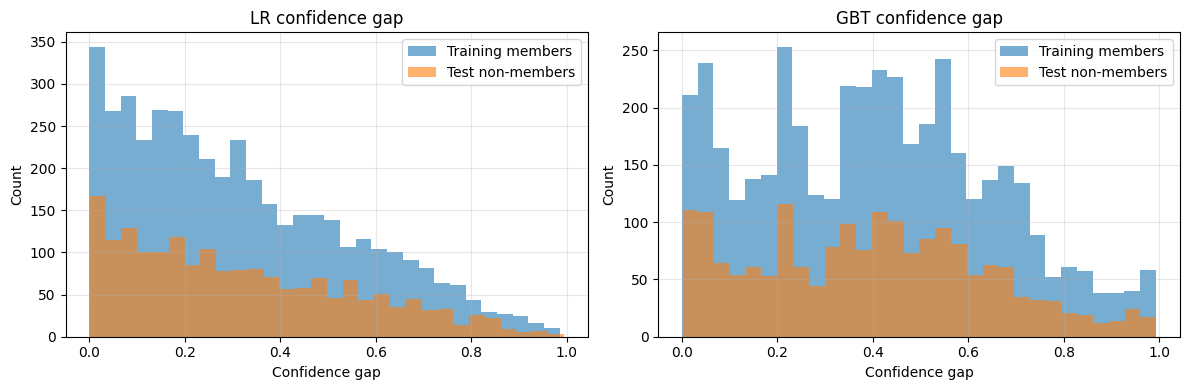

In [ ]:
# Part 3: confidence-gap histograms

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, result in zip(axes, [mi_lr, mi_gbt]):
    ax.hist(result["train_conf_gap"], bins=30, alpha=0.6, label="Training members")
    ax.hist(result["test_conf_gap"], bins=30, alpha=0.6, label="Test non-members")
    ax.set_title(f"{result['model']} confidence gap")
    ax.set_xlabel("Confidence gap")
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Part 3: generalization gap vs MI AUC

print("Generalization gap vs MI AUC")
print(df_mi_summary[["model", "generalization_gap", "MI_AUC"]].round(3).to_string(index=False))

higher_gap_model = df_mi_summary.sort_values("generalization_gap", ascending=False).iloc[0]["model"]
higher_mi_model = df_mi_summary.sort_values("MI_AUC", ascending=False).iloc[0]["model"]

print("\nDirectional check")
print("Model with larger generalization gap:", higher_gap_model)
print("Model with larger MI AUC:", higher_mi_model)

if higher_gap_model == higher_mi_model:
    print("The directional evidence supports the hypothesis that larger generalization gap predicts higher MI AUC.")
else:
    print("The directional evidence does not support the hypothesis in this two-model comparison.")

print("\nNote: with only two models, this is not a valid statistical regression test.")

Generalization gap vs MI AUC
model  generalization_gap  MI_AUC
   LR              -0.008    0.50
  GBT               0.080    0.51

Directional check
Model with larger generalization gap: GBT
Model with larger MI AUC: GBT
The directional evidence supports the hypothesis that larger generalization gap predicts higher MI AUC.

Note: with only two models, this is not a valid statistical regression test.


In [ ]:
# Part 3: L2 regularization sweep for LR

C_VALUES = [0.01, 0.1, 1.0, 10.0]

l2_records = []

for c_value in C_VALUES:
    def build_lr_c(c=c_value):
        return LogisticRegression(max_iter=1000, penalty="l2", C=c)

    result = run_shadow_mi_audit(build_lr_c, f"LR_C_{c_value}", n_shadow=10)

    l2_records.append({
        "C": c_value,
        "train_auc": result["train_auc"],
        "test_auc": result["test_auc"],
        "generalization_gap": result["generalization_gap"],
        "MI_AUC": result["MI_AUC"]
    })

df_l2 = pd.DataFrame(l2_records)

print("L2 regularization sweep")
print(df_l2.round(3).to_string(index=False))

L2 regularization sweep
    C  train_auc  test_auc  generalization_gap  MI_AUC
 0.01      0.726     0.732              -0.006   0.507
 0.10      0.727     0.734              -0.007   0.500
 1.00      0.727     0.735              -0.008   0.500
10.00      0.727     0.735              -0.008   0.504


The L2 sweep does not show a large privacy-performance tradeoff for LR. MI AUC remains close to 0.50 across all C values, and test AUC changes only slightly. C = 0.10 or C = 1.00 appear to be reasonable choices because they keep MI AUC near random guessing while maintaining similar test AUC.

In this experiment, regularization does not materially reduce privacy risk because the baseline LR model already has very low membership inference vulnerability.

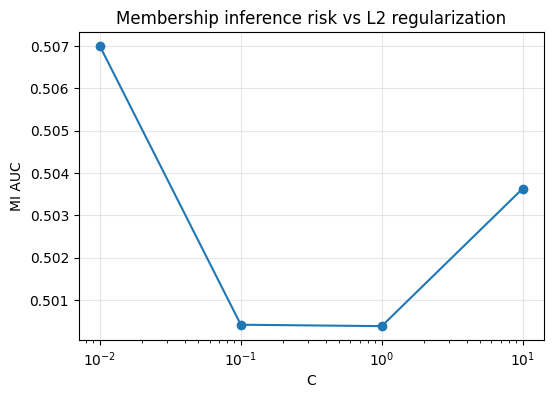

In [ ]:
# Plot MI AUC vs C

plt.figure(figsize=(6, 4))
plt.plot(df_l2["C"], df_l2["MI_AUC"], marker="o")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("MI AUC")
plt.title("Membership inference risk vs L2 regularization")
plt.grid(alpha=0.3)
plt.show()

#Conclusion

The highest-risk finding is the label-flip poisoning attack. This is the most concerning result because the attack remains largely invisible under aggregate performance monitoring. In the African-American-targeted poisoning variant, AIR increased from 1.961 at baseline to 2.860 at 30% poison rate, while AUC only changed from 0.735 to 0.731. This means the model can appear stable under standard AUC monitoring while producing a more severe disparate impact pattern.

A proactive mitigation would be stronger data provenance and label-integrity controls before training, especially for high-risk labels and subgroup-sensitive records. Based on the experiment, this mitigation should focus on preventing label corruption because PSI did not detect any feature drift. A reactive mitigation would be post-training subgroup fairness monitoring using AIR and FPR by race. In this output, an AIR-based monitor would flag all poison-rate scenarios because AIR remains outside [0.80, 1.25], while a PSI-only monitor would flag none of them.

The main disparate-impact concern is that mitigation cannot be evaluated only by AUC. A mitigation that keeps AUC stable may still leave African-American and Caucasian defendants with unequal false-positive behavior. Therefore, any deployment decision should require both aggregate performance checks and subgroup fairness checks before release.